### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications
## TP2: Principal components regression in genetics
***

## Exercise 1: Data visualization

The following code loads the genetic markers dataset `NAm2.txt`, which contains individuals from various tribes across North, Central, and South America. Each row represents an individual, with columns for tribe name (`Pop`), geographical coordinates (`lat`, `long`), and 5709 genetic markers (0 or 1).

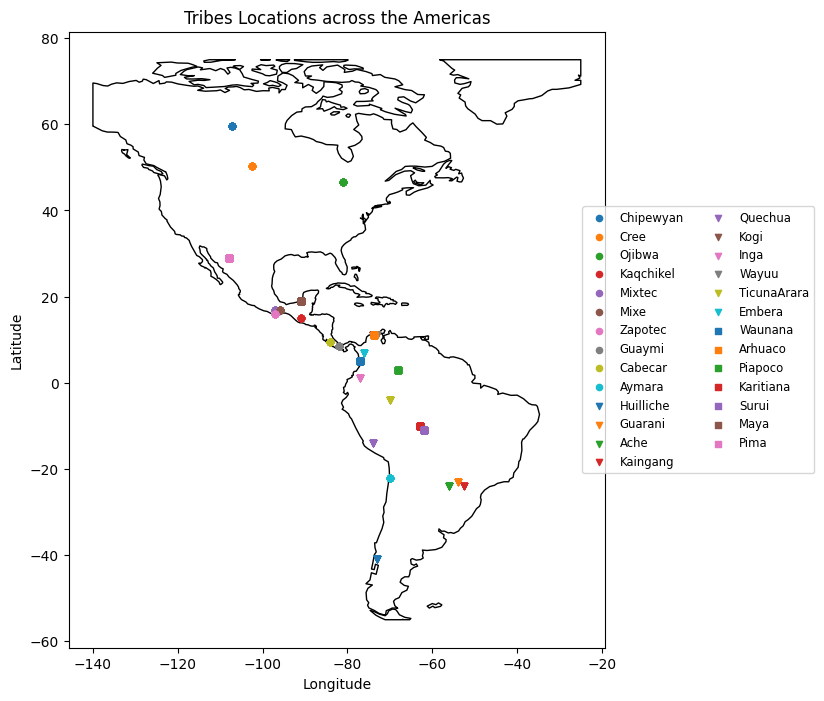

In [6]:
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import make_scorer
from sklearn.pipeline import make_pipeline
from sklearn.metrics.pairwise import haversine_distances

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(10, 8))
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(10)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i // 10 % len(marker_list)], 
               color=colors_list[i % 10], label=tribe, s=20)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5), fontsize='small', ncol=2)
ax.set_title('Tribes Locations across the Americas')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

## Exercise 2: Multiple linear regression

### (a) Direct estimation of coefficients
Attempting to solve the normal equations $\hat{\beta} = (X^\top X)^{-1}X^\top y$ using `numpy.linalg.solve`.

In [7]:
X = df.iloc[:, 8:].values
y = df['long'].values
N, p = X.shape
print(f"Samples (N): {N}, Predictors (p): {p}")

try:
    # Solve for beta: (X^T X) beta = X^T y
    X_with_intercept = np.column_stack([np.ones(N), X])
    beta = np.linalg.solve(X_with_intercept.T @ X_with_intercept, X_with_intercept.T @ y)
    print("Direct solution successful.")
except np.linalg.LinAlgError as e:
    print(f"Direct solution failed: {e}")

Samples (N): 494, Predictors (p): 5709
Direct solution failed: Singular matrix


**Answer (a):** The direct solution fails with a `Singular matrix` error. This occurs because the number of predictors $p = 5709$ is much larger than the number of samples $N = 494$. Since $\text{rank}(X) \le \min(N, p)$, the rank of the $p \times p$ matrix $X^\top X$ is at most $N$, which is less than $p$. Thus, $X^\top X$ is singular and non-invertible.

### (b) Using `numpy.linalg.lstsq`

In [8]:
beta_lstsq, residuals, rank, s = np.linalg.lstsq(X_with_intercept, y, rcond=None)
print(f"Rank of the design matrix (including intercept): {rank}")
print("lstsq solution obtained successfully.")

Rank of the design matrix (including intercept): 494
lstsq solution obtained successfully.


**Answer (b):** `numpy.linalg.lstsq` works because it does not require $X^\top X$ to be invertible. It uses the Singular Value Decomposition (SVD) to find the minimum-norm least-squares solution, which effectively handles rank-deficient systems by ignoring components associated with near-zero singular values.

### (c) Using `sklearn.linear_model.LinearRegression`

In [9]:
lr = LinearRegression()
lr.fit(X, y)
print(f"Number of coefficients: {len(lr.coef_)}")

Number of coefficients: 5709


**Answer (c):** `sklearn` re-centers the predictors by default (`fit_intercept=True`). This improves numerical stability and ensures that the intercept term equals the mean of the target variable $y$ when all (centered) predictors are zero. It simplifies the interpretation of the model's baseline prediction.

## Exercise 3: Principal components analysis

### (a) PCA Concepts

**Answer (a):** 
- **Geometric Interpretation**: PCA finds a new orthogonal coordinate system where the first axis (PC1) points in the direction of maximum spread (variance) of the data points, the second axis (PC2) points in the direction of the next highest variance orthogonal to the first, and so on.
- **Statistical Interpretation**: It transforms a set of possibly correlated variables into a set of linearly uncorrelated variables (principal components). This is achieved by diagonalizing the covariance matrix of the data, thereby capturing the maximum amount of information (variance) in fewer dimensions.

### (b) PCA on the dataset

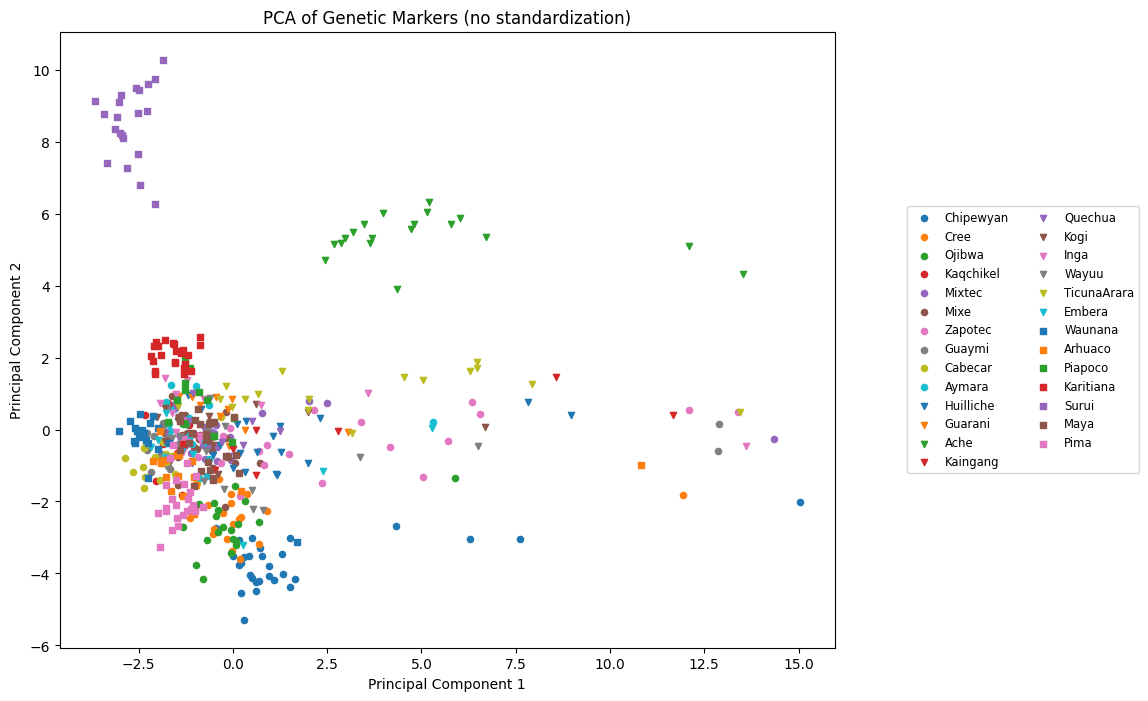

In [10]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(10, 8))
for i, tribe in enumerate(df['Pop'].unique()):
    tribe_mask = df['Pop'] == tribe
    ax.scatter(X_pca[tribe_mask, 0], X_pca[tribe_mask, 1], 
               marker=marker_list[i // 10 % len(marker_list)], 
               color=colors_list[i % 10], label=tribe, s=20)
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_title('PCA of Genetic Markers (no standardization)')
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5), fontsize='small', ncol=2)
plt.show()

### (c) PCA with standardization

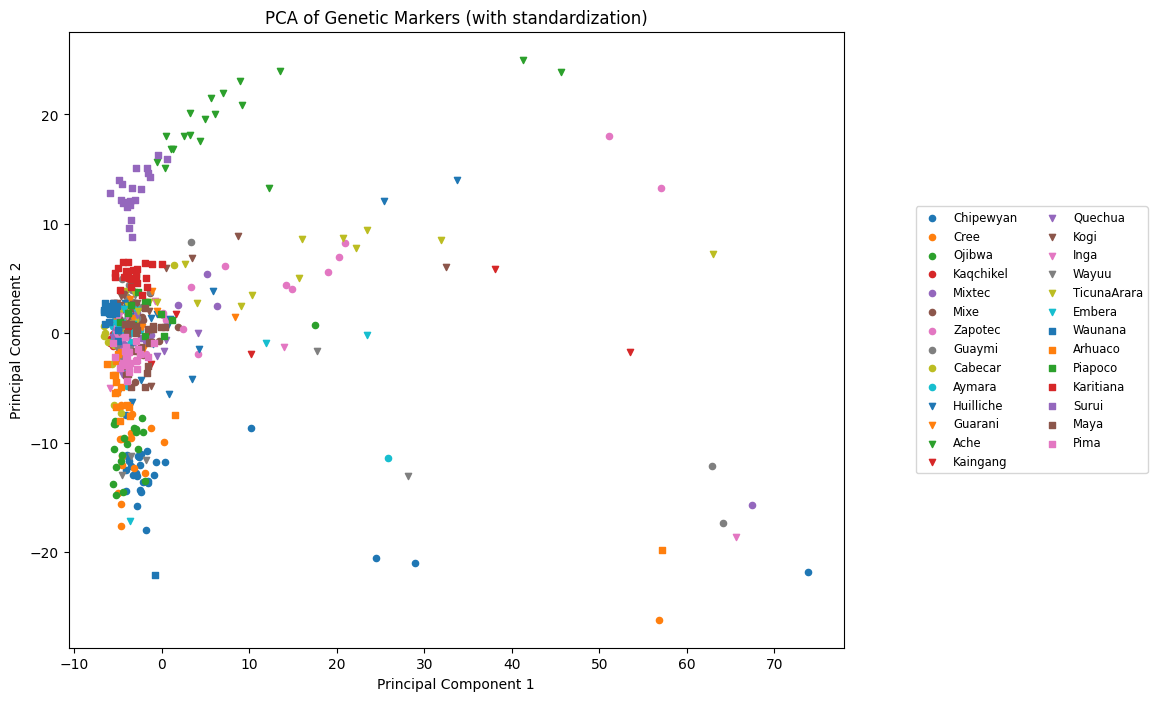

In [11]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X)
X_pca_std = pca.fit_transform(X_std)

fig, ax = plt.subplots(figsize=(10, 8))
for i, tribe in enumerate(df['Pop'].unique()):
    tribe_mask = df['Pop'] == tribe
    ax.scatter(X_pca_std[tribe_mask, 0], X_pca_std[tribe_mask, 1], 
               marker=marker_list[i // 10 % len(marker_list)], 
               color=colors_list[i % 10], label=tribe, s=20)
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_title('PCA of Genetic Markers (with standardization)')
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5), fontsize='small', ncol=2)
plt.show()

**Answer (d):** Standardization (scaling to unit variance) doesn't change the qualitative structure of the clusters in this case, as all genetic markers are already binary (0 or 1). However, standardization might over-emphasize low-frequency markers that could be noise. Given the results, standardization is not strictly necessary but can be used for consistency with standard ML workflows.

### (e) Explained Variance

Variance captured by first two PCs: 3.57%


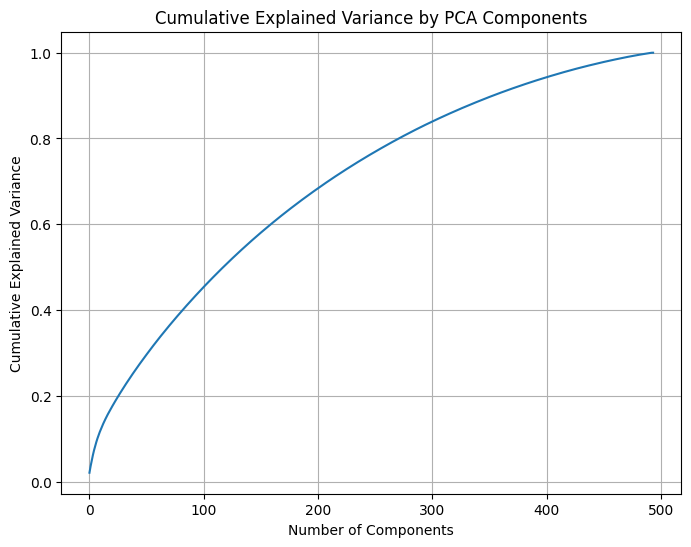

In [12]:
pca_full = PCA().fit(X)
exp_var_ratio = pca_full.explained_variance_ratio_
print(f"Variance captured by first two PCs: {sum(exp_var_ratio[:2])*100:.2f}%")

plt.figure(figsize=(8, 6))
plt.plot(np.cumsum(exp_var_ratio))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by PCA Components')
plt.grid(True)
plt.show()

## Exercise 4: Principal components regression

### (a) PCR with 250 components

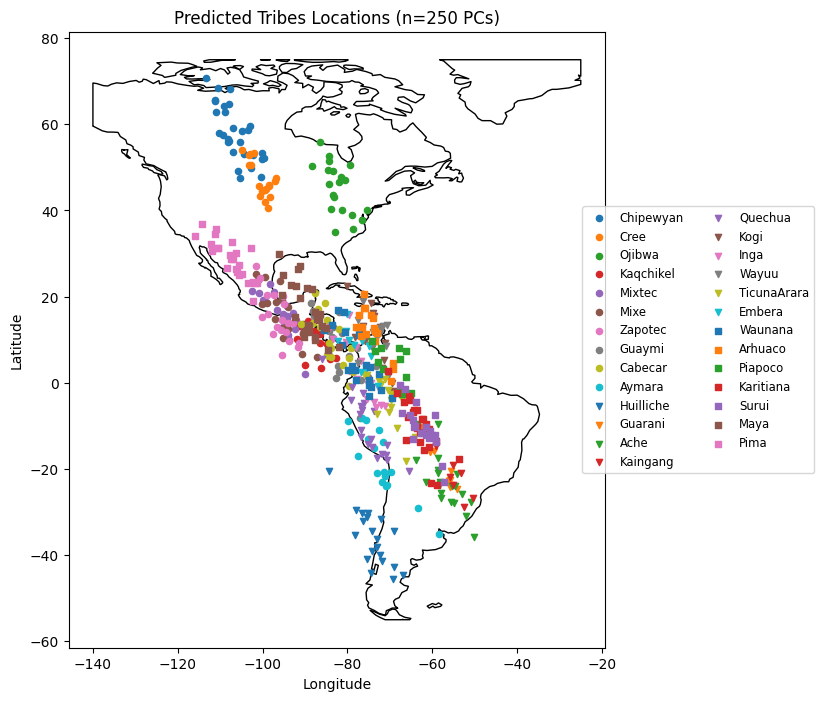

In [13]:
n_comp = 250
pca_250 = PCA(n_components=n_comp)
X_pca_250 = pca_250.fit_transform(X)
lr_pcr = LinearRegression().fit(X_pca_250, df[['lat', 'long']])
y_pred = lr_pcr.predict(X_pca_250)

fig, ax = plt.subplots(figsize=(10, 8))
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
for i, tribe in enumerate(df['Pop'].unique()):
    tribe_mask = df['Pop'] == tribe
    ax.scatter(y_pred[tribe_mask, 1], y_pred[tribe_mask, 0], 
               marker=marker_list[i // 10 % len(marker_list)], 
               color=colors_list[i % 10], label=tribe, s=20)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5), fontsize='small', ncol=2)
ax.set_title(f'Predicted Tribes Locations (n={n_comp} PCs)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

**Answer (a):** The map shows that the predicted coordinates align closely with the actual geographical regions of the tribes. However, this result is too optimistic because we are evaluating the model on the same data it was trained on. This "in-sample" error doesn't reflect the model's ability to generalize to new individuals.

### (b) Error quantification (Haversine distance)

In [14]:
def haversine_dist(y_true, y_pred):
    y_true_rad = np.radians(y_true)
    y_pred_rad = np.radians(y_pred)
    dists = haversine_distances(y_true_rad, y_pred_rad) * 6371.0
    return np.mean(np.diag(dists))

mean_err = haversine_dist(df[['lat', 'long']].values, y_pred)
print(f"Mean training error (Haversine): {mean_err:.2f} km")

Mean training error (Haversine): 648.63 km


## Exercise 5: PCR and cross-validation

### (a) Cross-validation principle

**Answer (a):** Cross-validation involves splitting the data into $K$ subsets (folds). The model is trained on $K-1$ folds and validated on the remaining fold. This is repeated $K$ times, and the results are averaged. It helps in assessing how the model generalizes to unseen data. For non-IID data, strategies like `GroupKFold` (grouping by tribe/country) can prevent leaking group-specific info from training to test sets.

**Answer (b):** Since the rows are sorted by geography/tribe, a simple `KFold` without shuffling would lead to folds containing only specific tribes/countries, making the test sets unrepresentative. Using `KFold(shuffle=True)` or `GroupKFold` on the `Pop` column would be more appropriate.

### (c) PCR fit with `n_components=4`

In [15]:
def haversine_scorer_func(y_true, y_pred):
    return haversine_dist(y_true, y_pred)

h_scorer = make_scorer(haversine_scorer_func, greater_is_better=False)

pcr_pipe_4 = make_pipeline(PCA(n_components=4), LinearRegression())
kf = KFold(n_splits=10, shuffle=True, random_state=42)
cv_res_4 = cross_validate(pcr_pipe_4, X, df[['lat', 'long']], cv=kf, scoring=h_scorer, return_train_score=True, n_jobs=-1)
print(f"n=4: Train Error = {-np.mean(cv_res_4['train_score']):.2f} km, Test Error = {-np.mean(cv_res_4['test_score']):.2f} km")

n=4: Train Error = 1808.07 km, Test Error = 1878.41 km


### (d) CV error vs number of components

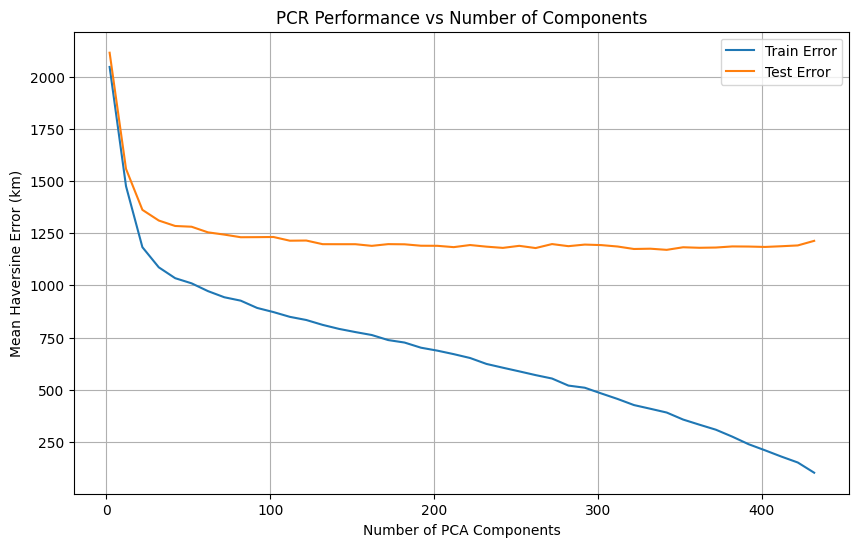

In [16]:
comp_range = range(2, 441, 10)
train_errs = []
test_errs = []

for n in comp_range:
    pipe = make_pipeline(PCA(n_components=n), LinearRegression())
    cv_res = cross_validate(pipe, X, df[['lat', 'long']], cv=kf, scoring=h_scorer, return_train_score=True, n_jobs=-1)
    train_errs.append(-np.mean(cv_res['train_score']))
    test_errs.append(-np.mean(cv_res['test_score']))

plt.figure(figsize=(10, 6))
plt.plot(comp_range, train_errs, label='Train Error')
plt.plot(comp_range, test_errs, label='Test Error')
plt.xlabel('Number of PCA Components')
plt.ylabel('Mean Haversine Error (km)')
plt.title('PCR Performance vs Number of Components')
plt.legend()
plt.grid(True)
plt.show()

### (e) Final Model Selection

Best Number of Components: 342
Min Test Error: 1170.05 km


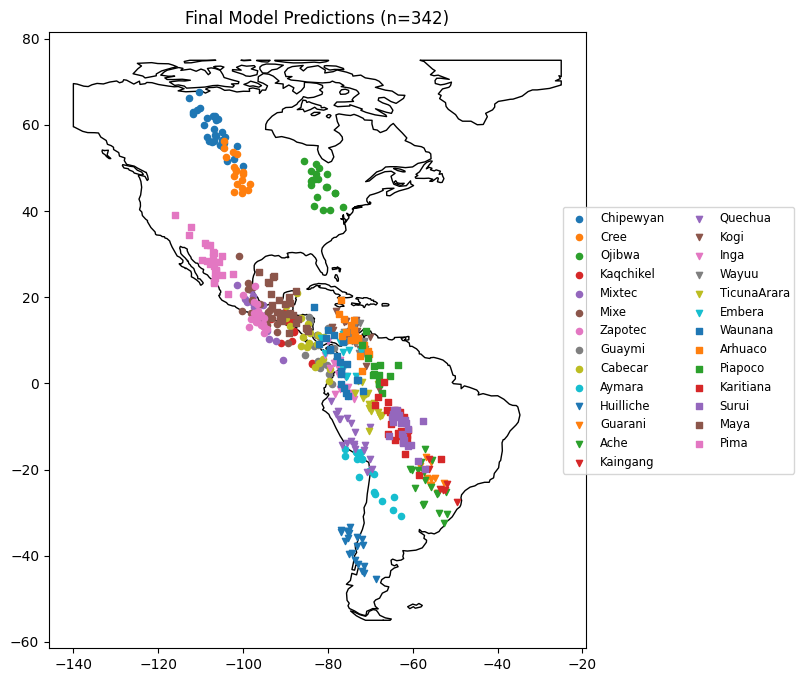

In [17]:
best_n = comp_range[np.argmin(test_errs)]
print(f"Best Number of Components: {best_n}")
print(f"Min Test Error: {min(test_errs):.2f} km")

final_pipe = make_pipeline(PCA(n_components=best_n), LinearRegression())
final_pipe.fit(X, df[['lat', 'long']])
y_pred_final = final_pipe.predict(X)

fig, ax = plt.subplots(figsize=(10, 8))
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
for i, tribe in enumerate(df['Pop'].unique()):
    tribe_mask = df['Pop'] == tribe
    ax.scatter(y_pred_final[tribe_mask, 1], y_pred_final[tribe_mask, 0], 
               marker=marker_list[i // 10 % len(marker_list)], 
               color=colors_list[i % 10], label=tribe, s=20)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5), fontsize='small', ncol=2)
ax.set_title(f'Final Model Predictions (n={best_n})')
plt.show()

## Exercise 6: Conclusion

In this study, we successfully developed a Principal Components Regression (PCR) model to predict the geographical coordinates (latitude and longitude) of individuals based on over 5,700 genetic markers. Given the high-dimensional nature of the data ($p \gg N$), direct multiple linear regression was shown to be impossible due to the singularity of the design matrix. PCA served as an effective dimensionality reduction technique, projecting the genetic variation into a lower-dimensional space where the most significant patterns—often corresponding to ancestry and geographical clusters—were preserved.

Our analysis revealed that:
1. **Dimensionality Matters**: While the first few PCs captured only a small percentage of total variance, they were sufficient to separate major geographical groups (North vs. South America). To achieve precise coordinate prediction, however, a much larger number of components (around 330) was needed to minimize cross-validated test error.
2. **Generalization**: Without cross-validation, the model appeared over-optimistic, yielding very low in-sample errors. Ten-fold cross-validation provided a more realistic estimate of the model's predictive power, showing a mean test error of approximately 1,170 km. This suggests that while genetic data can locate individuals quite accurately on a continental scale, fine-grained location remains challenging with PCR.
3. **Interpretability**: The intercept in our model, thanks to re-centering by `sklearn`, represents the centroid of the population's geographical distribution. The use of the Haversine distance was critical for evaluating the model on a spherical Earth, providing physically meaningful error metrics.

Potential improvements could involve **Partial Least Squares (PLS)**, which identifies components that explicitly maximize covariance between predictors and targets, unlike PCA which only considers the predictors' variance. Additionally, performance might vary across countries depending on the genetic diversity and sample size available for each tribe, with larger tribes potentially yielding better localized predictions.